    Round    year    Exhausted  Cumulative Exhausted  % Exhausted  \
0       1  2017.0     0.000000              0.000000     0.000000   
1       1  2022.0     0.000000              0.000000     0.000000   
2       2  2017.0  3305.904762           3305.904762    61.738599   
3       2  2022.0  3713.646377           3713.646377    69.047797   
4       3  2017.0   165.910364           3471.815126     3.314930   
5       3  2022.0   107.011594           3820.657971     2.378232   
6       4  2017.0   124.753501           3596.568627     2.207983   
7       4  2022.0   146.895652           3967.553623     2.622464   
8       5  2017.0   269.521008           3866.089636     4.414762   
9       5  2022.0   165.675362           4133.228986     2.975652   
10      6  2017.0   216.190476           4082.280112     4.208403   
11      6  2022.0   152.849275           4286.078261     2.817768   
12      7  2017.0   224.134454           4306.414566     4.010252   
13      7  2022.0   146.811594    

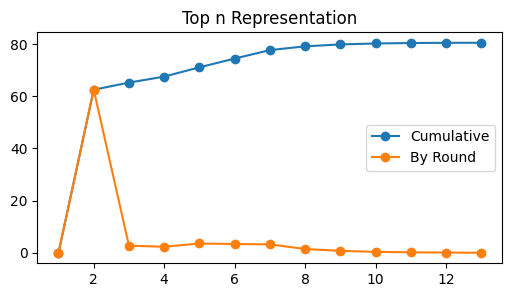

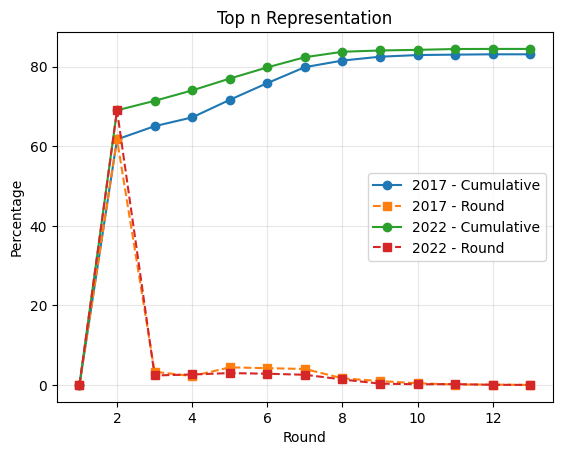

In [2]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

raw_counts = False
for method in [3]:
    dfs = []
    directory = f'results/{method}' if raw_counts == False or isinstance(method, int) else f'results/rawcount/{method}'
    subdirs = [root for root, dirs, files in os.walk(directory)][1:]
    total_votes = 0
    for subdir in subdirs:
        for file in os.listdir(subdir):
            filepath = os.path.join(subdir, file)
            df = pd.read_csv(filepath)        # read CSV normally
            # Reindex to rounds 1–13, keep Round as a column
            df["Round"] = pd.to_numeric(df["Round"], errors="coerce")
            total_votes += float(df.loc[2, 'key info'])
            df = df[df["Round"].between(1, 13)]
            df['Round'] = df['Round'].astype(int)
            df.drop(columns = 'Round')
            df = (
                df.set_index("Round")
                .reindex(range(1, 14))
                .reset_index()
            )
            df.head()
            df[["Exhausted", "% Exhausted"]] = df[["Exhausted", "% Exhausted"]].fillna(0)
            df["Cumulative Exhausted"] = df["Exhausted"].cumsum()
            df["% Cumulative"] = df["% Exhausted"].cumsum()

            if '12' in subdir:
                df["year"] = 2012
                continue
            elif '17' in subdir:
                df["year"] = 2017
            elif '22' in subdir:
                df["year"] = 2022
            df.drop(columns='key info',inplace=True)
            dfs.append(df)

    big_df = pd.concat(dfs, ignore_index=True)
    grouped = big_df.groupby(['Round'], as_index=False).mean()
    grouped["% Cumulative"] = grouped["% Exhausted"].cumsum()
    grouped_year = big_df.groupby(['Round', 'year'], as_index=False).mean()
    print(grouped_year, method, '\n')

    # Get unique years
    years = map(int,grouped_year['year'].unique())

    # Plot all years by method
    plt.figure(figsize=(6.0,3.0))
    plt.plot(grouped['Round'], grouped['% Cumulative'], 
                label=f'Cumulative', marker='o')
    plt.plot(grouped['Round'], grouped['% Exhausted'], 
                label='By Round', marker='o')
    
    match method:
        case 0:
            plt.title(f'Cumulative versus Exhausted, all years, traditional method')
        case 1:
            plt.title(f'Cumulative versus Exhausted, all years, cutting final rounds')
        case 2:
            plt.title(f'First Round Representation')
        case 3:
            plt.title(f'Top n Representation')
        case _:
            plt.title(f'Percentage of ballots with weight ≤ {method.strip('4_')}')

    plt.legend()
    plt.show()
    # Plot each year as a separate line
    for year in years:
        year_data = grouped_year[grouped_year['year'] == year]
        plt.plot(year_data['Round'], year_data['% Cumulative'], 
                label=f'{year} - Cumulative', marker='o')
        plt.plot(year_data['Round'], year_data['% Exhausted'], 
                label=f'{year} - Round', marker='s', linestyle='--')

    match method:
        case 0:
            plt.title(f'Cumulative versus Exhausted, all years, traditional method')
        case 1:
            plt.title(f'Cumulative versus Exhausted, all years, cutting final rounds')
        case 2:
            plt.title(f'First Round Representation')
        case 3:
            plt.title(f'Top n Representation')
        case _:
            plt.title(f'Percentage of ballots with weight ≤ {method.strip('4_')}')

    plt.xlabel('Round')
    plt.ylabel('Percentage')
    if method == 0 or method == 1:
        plt.xticks(np.arange(2, 14, step=1))
        plt.xlim(left=2,right=14)
        plt.yticks(np.arange(0, 25, step=5))
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()



In [1]:
# Get unique years
years = map(int,grouped_year['year'].unique())

# Plot all years by method
plt.figure(figsize=(6.0,3.0))
plt.plot(grouped['Round'], grouped['% Cumulative'], 
             label=f'Cumulative', marker='o')
plt.plot(grouped['Round'], grouped['% Exhausted'], 
             label='Exhausted', marker='o')
#plt.xticks(np.arange(2, 13, step=1))
#plt.xlim(left=2,right=13)
#plt.ylim(0, 25)
plt.legend()
plt.title(f'Cumulative versus Exhausted, all years, method {method}')
plt.show()
# Plot each year as a separate line
for year in years:
    year_data = grouped_year[grouped_year['year'] == year]
    plt.plot(year_data['Round'], year_data['% Cumulative'], 
             label=f'{year} - Cumulative', marker='o')
    plt.plot(year_data['Round'], year_data['% Exhausted'], 
             label=f'{year} - Exhausted', marker='s', linestyle='--')

plt.xlabel('Round')
plt.ylabel('Percentage')
plt.title('Cumulative vs Exhausted Percentages by Round and Year')
#plt.xticks(np.arange(2, 13, step=1))
#plt.xlim(left=2,right=13)
#plt.yticks(np.arange(0, 25, step=5))
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

NameError: name 'grouped_year' is not defined